In [1]:
import pandas as pd
import sqlite3

#load data
df = pd.read_csv('../data/diabetic_data.csv')

#connect to database
conn = sqlite3.connect('../hospital.db')

#creatate a table
df.to_sql('patients', conn, if_exists='replace', index=False)

#confirm 
pd.read_sql("SELECT * FROM patients LIMIT 5;", conn)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
#total patients 

pd.read_sql("""
SELECT COUNT(*) as total_patients
FROM patients;
""", conn)

,total_patients
0,101766


In [3]:
#Readmission Breakdown

pd.read_sql("""
SELECT readmitted, COUNT(*) as count
FROM patients
GROUP BY readmitted;
""", conn)

,readmitted,count
0,<30,11357
1,>30,35545
2,NO,54864


In [4]:
#Average Length of Stay

pd.read_sql("""
SELECT AVG(time_in_hospital) as avg_los
FROM patients;
""", conn)

,avg_los
0,4.395987


In [5]:
#ReadmissionRate by Age

pd.read_sql("""
SELECT age, 
        AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM patients
GROUP BY age
ORDER BY readmission_rate DESC;
""", conn)

,age,readmission_rate
0,[20-30),0.142426
1,[80-90),0.120835
2,[70-80),0.117731
3,[30-40),0.112318
4,[60-70),0.111284
5,[90-100),0.110992
6,[40-50),0.106040
7,[50-60),0.096662
8,[10-20),0.057887
9,[0-10),0.018634


In [6]:
#Do longer hospital stays increase readmission risk?

pd.read_sql("""
SELECT time_in_hospital,
        AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as patient_count
FROM patients
GROUP BY time_in_hospital
ORDER BY time_in_hospital;
""", conn)

,time_in_hospital,readmission_rate,patient_count
0,1,0.081785,14208
1,2,0.099396,17224
2,3,0.106668,17756
3,4,0.118070,13924
4,5,0.120309,9966
5,6,0.125879,7539
6,7,0.128350,5859
7,8,0.142337,4391
8,9,0.137242,3002
9,10,0.143467,2342


## SQL Analysis 

### Patient Volume
### Readmission Metrics
### Length of Stay Analysis 

In [7]:
import pandas as pd
import sqlite3

df = pd.read_csv('../data/diabetic_data.csv')
conn = sqlite3.connect('../hospital.db')

In [8]:
patients = df[['patient_nbr', 'age', 'gender']].drop_duplicates()
patients.to_sql('patient_table', conn, if_exists='replace', index=False)

73094

In [9]:
encounters = df[['encounter_id', 'patient_nbr', 'time_in_hospital', 'readmitted']]
encounters.to_sql('encounters', conn, if_exists='replace', index=False)

101766

In [10]:
utilization = df[['encounter_id', 'num_medications', 'number_outpatient', 'number_inpatient']]
utilization.to_sql('utilization', conn, if_exists='replace', index=False)

101766

In [14]:
pd.read_sql("""
SELECT p.age,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as patient_count
FROM encounters e
JOIN patient_table p
    ON e.patient_nbr = p.patient_nbr
GROUP BY p.age
ORDER BY readmission_rate DESC;
""", conn)

,age,readmission_rate,patient_count
0,[20-30),0.146636,1739
1,[80-90),0.121656,18092
2,[70-80),0.119705,27359
3,[30-40),0.113780,3955
4,[60-70),0.112532,23620
5,[90-100),0.111037,3017
6,[40-50),0.109093,10184
7,[50-60),0.099453,18089
8,[10-20),0.081267,726
9,[0-10),0.018405,163


In [16]:
pd.read_sql("""
SELECT e.time_in_hospital,
        AVG(u.num_medications) as avg_meds,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM encounters e
JOIN utilization u
    on e.encounter_id = u.encounter_id
GROUP BY e.time_in_hospital
ORDER BY e.time_in_hospital;
""", conn)

,time_in_hospital,avg_meds,readmission_rate
0,1,11.094243,0.081785
1,2,12.522062,0.099396
2,3,14.358414,0.106668
3,4,15.967107,0.118070
4,5,17.451836,0.120309
5,6,18.622231,0.125879
6,7,19.978495,0.128350
7,8,21.118880,0.142337
8,9,21.980680,0.137242
9,10,23.247225,0.143467


In [20]:
pd.read_sql("""
SELECT p.age,
        AVG(u.num_medications) as avg_meds,
        AVG(e.time_in_hospital) as avg_los,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as count
FROM encounters e 
JOIN patient_table p ON e.patient_nbr = p.patient_nbr
JOIN utilization u ON e.encounter_id = u.encounter_id
GROUP BY p.age
ORDER BY readmission_rate DESC
LIMIT 10;
""", conn)


,age,avg_meds,avg_los,readmission_rate,count
0,[20-30),12.089707,3.579643,0.146636,1739
1,[80-90),15.334623,4.786591,0.121656,18092
2,[70-80),16.432253,4.588435,0.119705,27359
3,[30-40),14.161820,3.806574,0.113780,3955
4,[60-70),17.191490,4.393776,0.112532,23620
5,[90-100),13.852171,4.753397,0.111037,3017
6,[40-50),15.501080,4.057345,0.109093,10184
7,[50-60),16.640666,4.139256,0.099453,18089
8,[10-20),8.356749,3.213499,0.081267,726
9,[0-10),6.165644,2.546012,0.018405,163


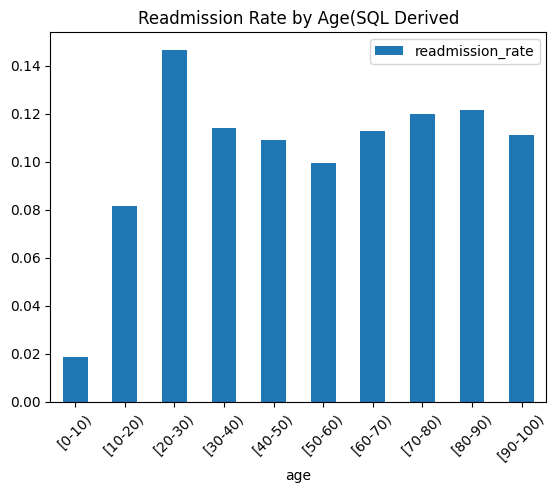

In [22]:
import matplotlib.pyplot as plt

df_sql = pd.read_sql("""
SELECT p.age,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM encounters e
JOIN patient_table p 
ON e.patient_nbr = p.patient_nbr
GROUP BY p.age
""", conn)

df_sql.plot(x='age', y='readmission_rate', kind='bar')
plt.title ("Readmission Rate by Age(SQL Derived")
plt.xticks(rotation=45)
plt.show()

## SQL-Based Analysis

### Muli_Table Querrying
### Readmission Risk by Demographics
### Clinical Complexity annd Outcomes

In [24]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../hospital.db')

In [25]:
#High Utilization 

pd.read_sql ("""
SELECT e.encounter_id,
        CASE
            WHEN (u.number_outpatient + u.number_inpatient) >= 3 THEN 1
            ELSE 0
        END AS high_utilizer,
        e.readmitted
FROM encounters e
JOIN utilization u
ON e.encounter_id = u.encounter_id
LIMIT 10;
""", conn)

,encounter_id,high_utilizer,readmitted
0,2278392,0,NO
1,149190,0,>30
2,64410,1,NO
3,500364,0,NO
4,16680,0,NO
5,35754,0,>30
6,55842,0,NO
7,63768,0,>30
8,12522,0,NO
9,15738,0,NO


In [28]:
#High Medicaftion Burden 

pd.read_sql("""
SELECT encounter_id,
        CASE
            WHEN time_in_hospital >= 7 THEN 1
            ELSE 0
        END AS long_stay,
        readmitted
FROM encounters;
""", conn)

,encounter_id,long_stay,readmitted
0,2278392,0,NO
1,149190,0,>30
2,64410,0,NO
3,500364,0,NO
4,16680,0,NO
...,...,...,...
101761,443847548,0,>30
101762,443847782,0,NO
101763,443854148,0,NO
101764,443857166,1,NO


In [30]:
#High Medication Burden 

pd.read_sql("""
SELECT encounter_id,
        CASE
            WHEN num_medications >=15 THEN 1
            ELSE 0
        END AS high_med_burden
FROM utilization;
""", conn)

,encounter_id,high_med_burden
0,2278392,0
1,149190,1
2,64410,0
3,500364,1
4,16680,0
...,...,...
101761,443847548,1
101762,443847782,1
101763,443854148,0
101764,443857166,1


In [35]:
#Combined cohorts 

pd.read_sql("""
SELECT e.encounter_id,
        p.age,
        e.time_in_hospital,
        u.num_medications,

        CASE
            WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0
        END AS high_utilizer,

        CASE
            WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0
        END AS long_stay,

        CASE
            WHEN u.num_medications >= 15 THEN 1 ELSE 0
        END AS high_med_burden,

        CASE
            WHEN e.readmitted = '<30' THEN 1 ELSE 0
        END AS readmitted_flag

FROM encounters e
JOIN patient_table p ON e.patient_nbr = p.patient_nbr
JOIN utilization u ON e.encounter_id = u.encounter_id;
""", conn)
            

,encounter_id,age,time_in_hospital,num_medications,high_utilizer,long_stay,high_med_burden,readmitted_flag
0,2278392,[0-10),1,1,0,0,0,0
1,149190,[10-20),3,18,0,0,1,0
2,64410,[20-30),2,13,1,0,0,0
3,500364,[30-40),2,16,0,0,1,0
4,16680,[40-50),1,8,0,0,0,0
...,...,...,...,...,...,...,...,...
106939,443847548,[70-80),3,16,0,0,1,0
106940,443847782,[80-90),5,18,0,0,1,0
106941,443854148,[70-80),1,9,0,0,0,0
106942,443857166,[80-90),10,21,0,1,1,0


In [41]:
#Readmission Rate

pd.read_sql("""
SELECT
    high_utilizer,
    AVG(readmitted_flag) as readmission_rate,
    COUNT(*) as count
FROM (
    SELECT e.encounter_id,
            CASE 
                WHEN (u.number_outpatient + u.number_inpatient) >= 3 THEN 1 
                ELSE 0 
            END as high_utilizer,
            CASE 
                WHEN e.readmitted = '<30' THEN 1 
                ELSE 0 
            END as readmitted_flag
    FROM encounters e
    JOIN utilization u 
        ON e.encounter_id = u.encounter_id
)
GROUP BY high_utilizer;
""", conn)

,high_utilizer,readmission_rate,count
0,0,0.099121,88528
1,1,0.195045,13238


In [64]:
#long stay 

pd.read_sql("""
SELECT
    CASE 
        WHEN time_in_hospital >=7 THEN 1 
        ELSE 0 
    END as long_stay,
    AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count
fROM encounters
GROUP BY long_stay;
""", conn)
    
    

,long_stay,readmission_rate,count
0,0,0.106181,80617
1,1,0.132252,21149


In [65]:
#Medical Burden

pd.read_sql("""
SELECT
    CASE WHEN num_medications >=15 THEN 1 ELSE 0 END as high_med_burden,
    AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count
FROM utilization u
JOIN encounters e ON u.encounter_id = e.encounter_id
GROUP BY high_med_burden;
""", conn)

,high_med_burden,readmission_rate,count
0,0,0.098578,49453
1,1,0.123908,52313


In [66]:
#Combination of above 

pd.read_sql("""
SELECT
    (CASE WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0 END +
     CASE WHEN e.time_in_hospital >=7 THEN 1 ELSE 0 END +
     CASE WHEN u.num_medications >=15 THEN 1 ELSE 0 END) AS risk_score,
    AVG(CASE WHEN e.readmitted ='<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count

FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id

GROUP BY risk_score
ORDER BY risk_score;
""", conn)
    

,risk_score,readmission_rate,count
0,0,0.086489,40271
1,1,0.113510,38860
2,2,0.146474,20065
3,3,0.203891,2570


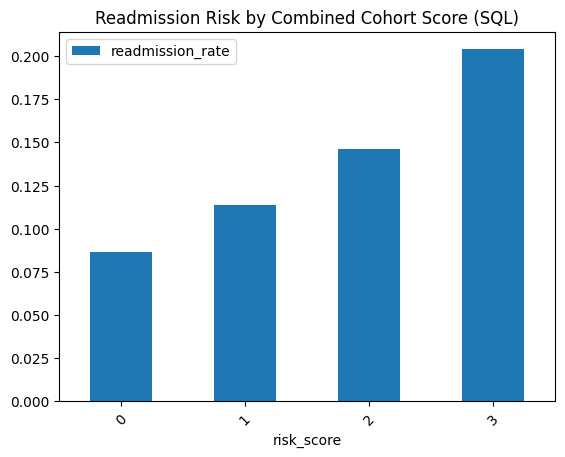

In [68]:
#Visual from above 

df_cohort = pd.read_sql("""
SELECT
    (CASE WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0 END +
     CASE WHEN e.time_in_hospital >=7 THEN 1 ELSE 0 END +
     CASE WHEN u.num_medications >=15 THEN 1 ELSE 0 END) AS risk_score,
    AVG(CASE WHEN e.readmitted ='<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count

From encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id

GROUP BY risk_score
ORDER BY risk_score;
""", conn)

import matplotlib.pyplot as plt

df_cohort.plot (x='risk_score', y='readmission_rate', kind='bar')
plt.title("Readmission Risk by Combined Cohort Score (SQL)")
plt.xticks(rotation=45)

plt.show()

## Cohort-Based Insights

- High utilizers demonstrateed significantly higher readmission rates, indicating recurrent healthcare interactions as a key signal.

- Patients with prolonged hospital stays also showed elevated risk, suggesting increase in clinical severity.

- A combined cohort-base risk score showed a strong stepwise increase in readmission probability, reinforcing the value of multi-factor risk stratification 